# 1. Data Preperation
## 1.1 Load Modules

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cmcrameri.cm as cmc
import hvplot.xarray

## 1.2 Download data

the data was downloaded yousing the following *Google Earth Engine* script: https://code.earthengine.google.com/04afb4de7a1d95d988d2972e3ed87ffd.
--> downloads image from July 1st of the START year of each 3-year block

Band positions: *1. Blue, 2. Green , 3. Red, 4. NIR, 5. SWIR1, 6. SWIR2, 7. TIR1*


## 1.3 Load Data 

In [2]:
year_list = np.arange(1985, 2025, 3) # array with al the year we have data from
LST = xr.Dataset()

LST_array = []
Red_array = []
NIR_array = []
for year in year_list:
        filepath = f"../data/raw/LandsatComposite_Zurich_{year}.tif"
        with xr.open_dataset(filepath, engine = "rasterio") as src:
            src_t = src.expand_dims(time=[year])# add time as a coordinate
            LST_array.append(src_t.sel(band = 7).band_data)
            Red_array.append(src_t.sel(band = 3).band_data)
            NIR_array.append(src_t.sel(band = 4).band_data)


LST = xr.concat(LST_array, dim="time")# turn into xr data array
LST = LST - 273.15 # turn into °C
Red = xr.concat(Red_array, dim = "time")
NIR = xr.concat(NIR_array, dim = "time")


## 1.4 RGB picture for reference
This codeblock generates a true color image to give contex to the following analysis

Text(0.5, 1.0, 'Zürich 2024')

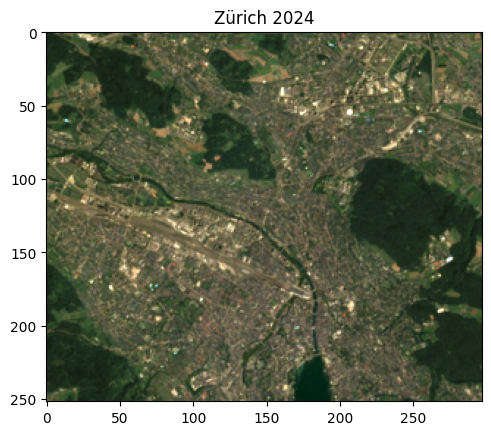

In [3]:
#reference Picture

def normalize(array, vmin=0, vmax=0.2):
    """Normalize and clip array to a specific range (default 0 to 0.4)"""
    # Clip the array to the specified vmin and vmax
    clipped = np.clip(array, vmin, vmax)
    # Scale the clipped array to 0-1 for display
    return (clipped - vmin) / (vmax - vmin)

with xr.open_dataset("../data/raw/LandsatComposite_Zurich_2024.tif", engine = "rasterio") as src:
            Blue_ref = normalize(src.sel(band = 1).band_data)
            Green_ref = normalize(src.sel(band = 2).band_data)
            Red_ref = normalize(src.sel(band=3).band_data)

rgb = np.dstack((Red_ref, Green_ref, Blue_ref))

fig, ax = plt.subplots()

ax.imshow(rgb)
ax.set_title("Zürich 2024")

# 2. How did LST and NDVI change from 1985 to 2024?
## 2.1 Simple Visualization of change
This code produces interactive hvplot animations of LST and NDVI at the different years

In [4]:

NDVI = (NIR - Red)/(NIR + Red)
print(NDVI.min().item(), NDVI.max().item())## shuoul not be > 1

-1.1360201511334964 5.706766917293946


In [20]:
def limits(array, p = 2):
    vmin = np.percentile(array, p)
    vmax = np.percentile(array, 100-p)
    return vmin, vmax
    

#plot LST
LST_min_hv, LST_max_hv = limits(LST)

LST_hvplot = LST.hvplot(x = "x", y = "y", groupby = "time", cmap = cmc.lajolla_r,
              clim = (LST_min_hv, LST_max_hv),
              clabel = "Land Surface Temperature [°C]", 
              aspect='equal', 
              xaxis = None, yaxis = None)



#plot NDVI
NDVI_min_hv, NDVI_max_hv = limits(NDVI) 
#NDVI_max_hv=np.percentile(NDVI, 98)               #only max used -->almost no negative values
NDVI_hvplot = NDVI.hvplot(x = "x", y = "y", groupby = "time", cmap = cmc.tokyo,
              clim = (0, NDVI_max_hv),
              clabel = "NDVI", 
              aspect='equal',
              shared_axes = False, 
              xaxis = None, yaxis = None)


LST_hvplot + NDVI_hvplot

BokehModel(combine_events=True, render_bundle={'docs_json': {'d6d47fb6-0b81-4e72-bcd4-6245c791e393': {'version…

## 2.2 NDVI change in reference to 1985
This code calculates the difference of each layer to the reference year creates an animation through time


In [6]:
#calculate difference 
NDVI_dif = NDVI.sel(time = slice(1988,2024)) - NDVI.sel(time = 1985)

#set boundaries for visualisation centerd around 0
NDVI_min, NDVI_max = limits(NDVI_dif)
NDVI_boundry = max(abs(NDVI_min), abs(NDVI_max))# center around 0

#animate NDVI
NDVI_dif.hvplot(x = "x", y = "y", groupby = "time", cmap = cmc.bam,
              clim = (-NDVI_boundry, NDVI_boundry),
              clabel = "Change in NDVI in reference to 1985", 
              aspect='equal', 
              xaxis = None, yaxis = None,
              widget_location = "bottom",
              widget_type = "scrubber")

BokehModel(combine_events=True, render_bundle={'docs_json': {'052c174d-e643-44ae-b509-5a79f790aca8': {'version…

##  2.3 Modelling change in Collapsed space
In this Segment, the spatial extent of the data is collapsed into means, resulting in one overall value per 3-annual period. To these values, a linear model is fitted to measure the rate of change.

Text(0.5, 0, 'year')

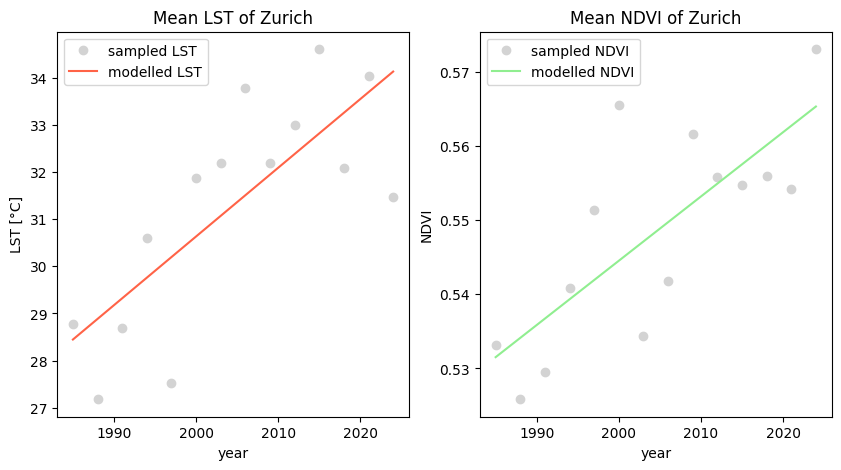

In [7]:
# change in overall NDVI

NDVI_mean = NDVI.mean(dim =["x","y"])

NDVI_mean_fit = NDVI_mean.polyfit(dim = "time", deg = 1)
NDVI_mean_trend_line = xr.polyval(NDVI_mean.time, NDVI_mean_fit.polyfit_coefficients)

# change in overall LST
LST_mean = LST.mean(dim =["x","y"])
LST_mean_fit = LST_mean.polyfit(dim = "time", deg = 1)
LST_mean_trend_line = xr.polyval(LST_mean.time, LST_mean_fit.polyfit_coefficients)

#plotting
fig, ax = plt.subplots(1,2, figsize = (10,5))

LST_mean.plot(ax = ax[0],marker = "o", ls= "", label = "sampled LST", color = "lightgrey")
LST_mean_trend_line.plot(ax = ax[0], label = "modelled LST", color = "tomato")
ax[0].set_title("Mean LST of Zurich")
ax[0].legend()
ax[0].set_ylabel("LST [°C]")
ax[0].set_xlabel("year")

NDVI_mean.plot(ax = ax[1], marker = "o", ls = "", label = "sampled NDVI", color = "lightgrey")
NDVI_mean_trend_line.plot(ax= ax[1], label = "modelled NDVI", color = "lightgreen")
ax[1].set_title("Mean NDVI of Zurich")
ax[1].legend()
ax[1].set_ylabel("NDVI")
ax[1].set_xlabel("year")

#### NDVI explaination:
wahrscheinlich nicht siginfikant (ein Punkt im Wald ähnliche SChwankungen (siehe unten))--> evtl auch aufgrund unterschiedlichen Satelitten

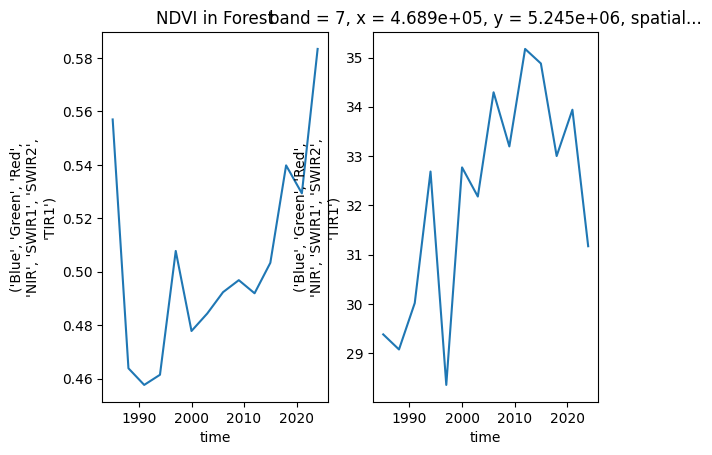

In [27]:
coordinates = (2683638.80, 1246727.00)# coordinates in LV95 WHy??????

point_NDVI = NDVI.sel(x= coordinates[1], y = coordinates[0], method = "nearest")
point_LST = LST.sel(x= coordinates[1], y = coordinates[0], method = "nearest")

fig, ax = plt.subplots(1,2)
point_NDVI.plot(ax = ax[0])## = Background change between years
ax[0].set_title("NDVI in Forest")

point_LST.plot(ax = ax[1])


## 2.4 Modelling Change pixelwise
Here, similarly to 2.3, the rate of change is measured using a linear regression, but this time a regrssion is fitted for every pixel seperatly.

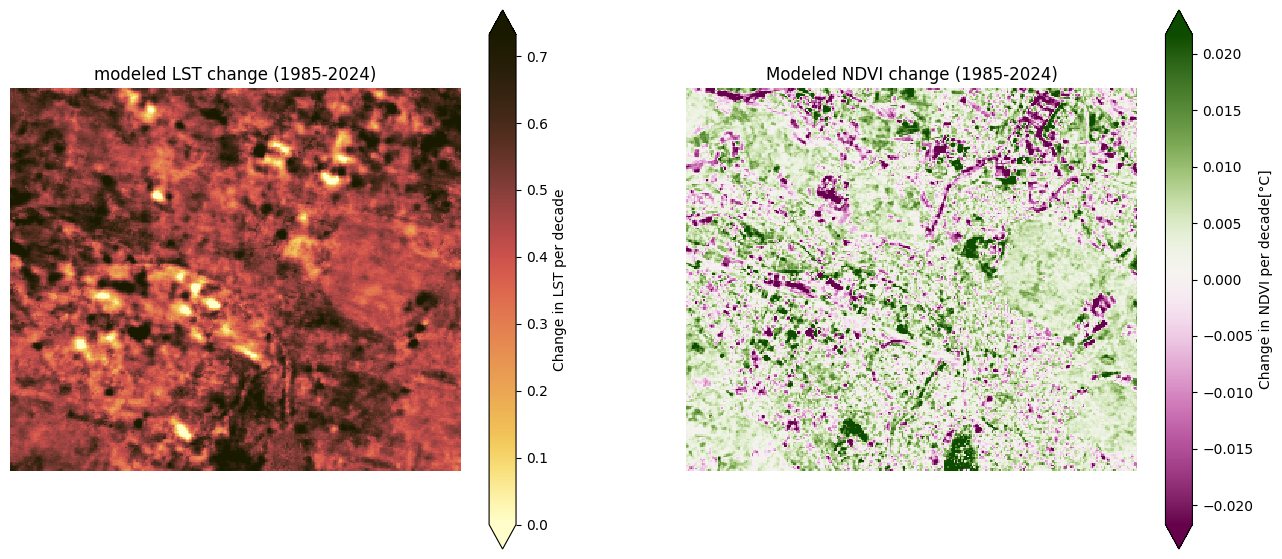

In [8]:

NDVI_fit = NDVI.polyfit(dim = "time", deg = 1)
NDVI_slope10 = NDVI_fit.polyfit_coefficients.sel(degree = 1)/3*10

# change in overall LST
LST_fit = LST.polyfit(dim = "time", deg = 1)
LST_slope10 = LST_fit.polyfit_coefficients.sel(degree = 1)/3*10 # slope is in 3 year increments (int not dateTime!)

#plotting
fig, ax = plt.subplots(1,2, figsize = (16,7))

# plot slope of LST
LST_slope_min, LST_slope_max = limits(LST_slope10)
LST_slope_boundry = max(abs(LST_slope_min), abs(LST_slope_max))

LST_slope10.plot(ax=ax[0], 
                 vmin = 0 ,
                 vmax = LST_slope_boundry, 
                 cmap = cmc.lajolla_r,
                 cbar_kwargs = {"label" : "Change in LST per decade"})
ax[0].set_axis_off()
ax[0].set_title("modeled LST change (1985-2024)")
ax[0].set_aspect('equal')

#plot slope of NDVI
NDVI_slope_min, NDVI_slope_max = limits(NDVI_slope10)
NDVI__slope_boundry = max(abs(NDVI_slope_min), abs(NDVI_slope_max))

NDVI_slope10.plot(ax= ax[1], 
                  vmin = - NDVI__slope_boundry, 
                  vmax = NDVI__slope_boundry, 
                  cmap = cmc.bam, 
                  cbar_kwargs = {"label" : "Change in NDVI per decade[°C]"})
ax[1].set_axis_off()
ax[1].set_title("Modeled NDVI change (1985-2024)")
ax[1].set_aspect('equal')

# 3. How do NDVI und LST correlate?
## 3.1 Analysis of one year

(0.0, 1.0)

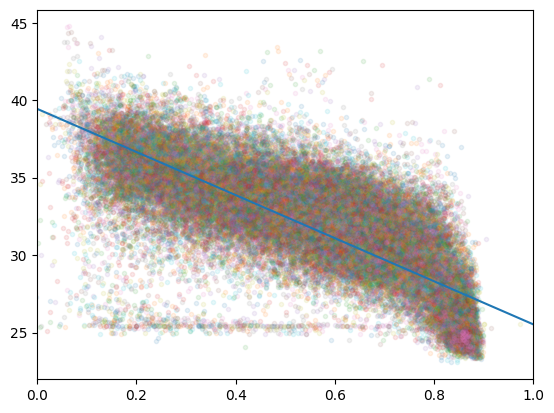

In [ ]:
#extract 2024 data
year = 2024 ## change year
NDVI_2024 = NDVI.sel(time = year, method = "nearest")
LST_2024 = LST.sel(time=year, method = "nearest")

# calculate correlation
LST_NDVI_2024 = np.polyfit(NDVI_2024.values.flatten(), LST_2024.values.flatten(), deg = 1)
intercept = LST_NDVI_2024[1]
slope = LST_NDVI_2024[0]

#plot LST against NDVI
fig, ax = plt.subplots()
ax.plot(NDVI_2024, LST_2024, marker = ".", ls = "", alpha = 0.1)
ax.axline((0,intercept),slope=slope)
ax.set_xlim(xmin = 0, xmax= 1)


kommentar: feld unten = see --> rausrechnen!

Gesamte Zeit

(0.0, 1.0)

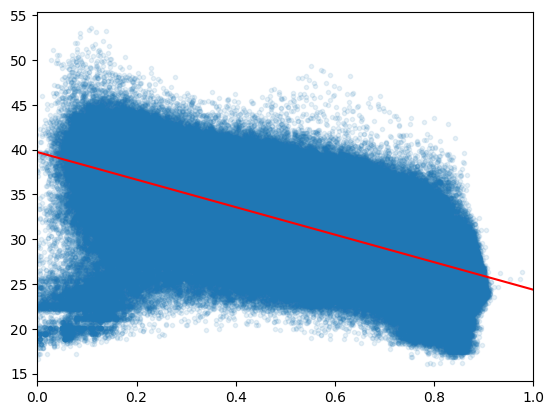

In [69]:


# calculate correlation
LST_NDVI= np.polyfit(NDVI.values.flatten(), LST.values.flatten(), deg = 1)
intercept = LST_NDVI[1]
slope = LST_NDVI[0]

#plot LST against NDVI
fig, ax = plt.subplots()
ax.plot(NDVI.values.flatten(), LST.values.flatten(), marker = ".", ls = "", alpha = 0.1)
ax.axline((0,intercept),slope=slope, color = "red")
ax.set_xlim(xmin = 0, xmax= 1)


/////OLD

# change in LST explained by NDVI 
lol scwirig wel LST ja aus sut sich gänderet het..

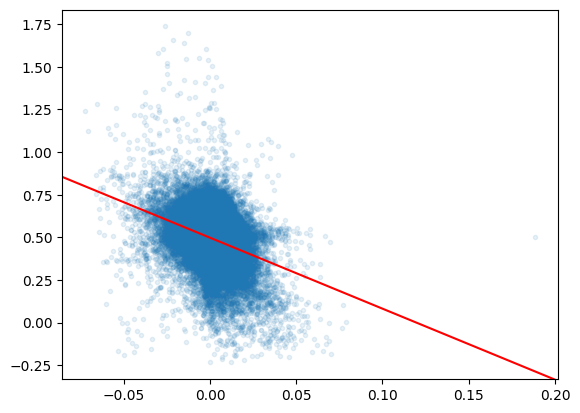

In [71]:
flat_LST_slope = LST_slope10.values.flatten()
flat_NDVI_slope = NDVI_slope10.values.flatten()

LST_NDVI = np.polyfit(flat_NDVI_slope,flat_LST_slope, deg = 1)

intercept = LST_NDVI[1]
slope = LST_NDVI[0]

fig, ax = plt.subplots()
ax.plot(flat_NDVI_slope, flat_LST_slope, marker = ".", ls = "", alpha = 0.1)
ax.axline((0,intercept),slope=slope, color = "red")


Wahrscheinlich zu abstrakt, grösster teil der LSt_change explained durch climate change

?? simple cahngmap in lST

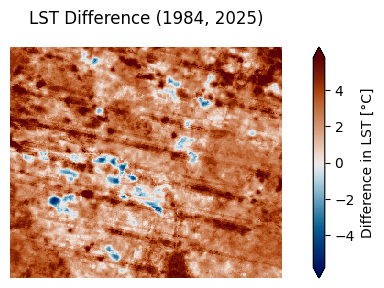

In [12]:
# extract year values from data Cube
LST_2024 = LST.sel(time = 2024)
LST_1985 = LST.sel(time = 1985)

dif_LST = LST_2024 - LST_1985 ## halt tagesabhängig, noch überlegen ob das sinn macht

fig , ax = plt.subplots(figsize = (8,3))

#determine vmin/max LST
LST_min = np.percentile(dif_LST, 2)# percentile to crop outliers
LST_max = np.percentile(dif_LST.values, 98)
LST_bound = max(abs(LST_min), abs(LST_max))# center around 0
#plot LST
dif_LST.plot(ax=ax,
            vmin = - LST_bound, 
            vmax = LST_bound,
            cmap = cmc.vik,
              cbar_kwargs = {"label": "Difference in LST [°C]"}) ##band in Kelvin
ax.set_axis_off()
ax.set_title("LST Difference (1984, 2025)")
ax.set_aspect('equal')


## note: for reference: add lables, context etc. lake etc...> mask for lake